In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""loftee_categories""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
…,…,…,…,…
"""all_encode_annotations""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""all_encode_annotations""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""all_encode_annotations""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

variant_filter_label = "missense"  # ← change per run: "Gene body", "CDS", "Non-CDS", "Intronic", etc.

anno = (
    anno
    .with_columns(
        core_promoter = pl.col('dist_to_tss').abs() <= 50,
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_annotated = pl.col('not_annotated_in_encode') == False,
        canonical_splice_variant = (pl.col('consequence_splice_acceptor_variant') == True) | (pl.col('consequence_splice_donor_variant') == True)
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),
        # (pl.col('consequence_upstream_gene_variant') == True),
        # (pl.col('consequence_downstream_gene_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # ((pl.col('dist_to_tss') < max_range) & (pl.col('dist_to_tss') > min_range)),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose regulatory region
        # (pl.col('not_in_encode') == False),
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),
        
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique()))
    )
    
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
    .with_columns(
        indel_length = (pl.col('ref').str.len_chars() - pl.col('alt').str.len_chars()).abs(),
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_gt2bp = pl.when(pl.col('deletion') & (pl.col('indel_length') >= 2)).then(True).otherwise(False),
        deletion_gt5bp = pl.when(pl.col('deletion') & (pl.col('indel_length') >= 5)).then(True).otherwise(False),
        insertion_gt2bp = pl.when(pl.col('insertion') & (pl.col('indel_length') >= 2)).then(True).otherwise(False),
        insertion_gt5bp = pl.when(pl.col('insertion') & (pl.col('indel_length') >= 5)).then(True).otherwise(False),
    )
    .with_columns(
        # --- ENCODE indels ---
        encode_deletion = pl.when(pl.col('deletion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_insertion = pl.when(pl.col('insertion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_snp = pl.when((pl.col('encode_annotated')==True) & (pl.col('deletion')==False) & (pl.col('insertion')==False)).then(True).otherwise(False),
    )
)


# selected_categories = ['genomic_region'] # genomic_region
# selected_categories = ['plof_consequences'] # plof consequences
# selected_categories = ['loftee_categories'] # loftee consequences
# selected_categories = ['plof_consequences', 'missense'] # CDS
selected_categories = ['protein_domains'] # Protein Domains
# selected_categories = ['loftee_protein_domains'] # LOFTEE Protein Domains
# selected_categories = ['splicing'] # Splicing
# selected_categories = ['non_coding_regions'] # Non-coding regions
# selected_categories = ['in_or_del'] # encode
# selected_categories = ['in_or_del', 'indel_lengths'] # indel length
# selected_categories = ['indel_cds'] # CDS indels
# selected_categories = ['encode_indels'] # encode indels
# selected_categories = ['encode_deletions'] # encode deletions
# selected_categories = ['all_encode_annotations'] # encode regions
# selected_categories = ['5utr_annotator'] # 5utr

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_237708/820833691.py:106: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_237708/820833691.py:115: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,ted_domain,low_complexity_domain,mobi_lip_full,mobi_curated_disorder_priority,region
str,bool,bool,bool,bool,str
"""chr2:178795028:T:C""",false,false,false,false,"""ENSG00000155657"""
"""chr11:63290536:A:C""",false,false,false,false,"""ENSG00000184999"""
"""chr2:96265270:C:G""",true,false,false,false,"""ENSG00000135956"""
"""chr8:80487528:A:G""",false,false,true,false,"""ENSG00000205189"""
"""chr1:150557191:C:T""",false,false,false,false,"""ENSG00000143382"""
…,…,…,…,…,…
"""chr1:159713719:C:T""",true,false,false,false,"""ENSG00000132693"""
"""chr17:7462167:T:C""",false,false,true,false,"""ENSG00000174282"""
"""chr2:32948891:G:A""",false,false,false,false,"""ENSG00000049323"""


In [5]:
# Handle fillna annotations
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    .with_columns(
        # Changed because we have binary annotations
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )
    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_237708/1210521968.py:70: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr19:6853034:T:C""","""ENSG00000141968""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr16:67192771:C:A""","""ENSG00000205250""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr10:93066164:A:T""","""ENSG00000187553""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr19:17194791:A:G""","""ENSG00000099331""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr7:5652422:C:A""","""ENSG00000011275""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
…,…,…,…,…,…,…
"""chr2:178545883:C:T""","""ENSG00000155657""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr19:6772851:G:A""","""ENSG00000141968""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0
"""chr11:64650498:G:A""","""ENSG00000110076""","""low_complexity_domain""",0.0,"""protein_domains""",1,0.0


In [6]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [7]:
n_steps = 101
or_threshold_pheno_left = 1
or_threshold_pheno_right = 1e-5

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_left),
    np.log10(or_threshold_pheno_right),
    num=n_steps
)

# Cast to float32 first
cutoffs_f32 = cutoffs_list.astype(np.float32)

# Then add, z-score: 0.4481 --> Quantile threshold: 0.6730
cutoffs_f32 = np.append(cutoffs_f32, np.float32(0.6730))

# Prepare cutoffs sorted and deduplicated
cutoffs_sorted = (
    pl.LazyFrame({"pheno_cutoff": cutoffs_f32.tolist()})
    .unique()
    .sort('pheno_cutoff')
    .collect()
)

# Convert percentile cutoffs to z-score thresholds (assuming standard Gaussian)
cutoffs_sorted = cutoffs_sorted.with_columns(
    zscore_cutoff = pl.Series('zscore_cutoff', stats.norm.ppf(cutoffs_sorted['pheno_cutoff'].to_numpy()))
)

print(f"Total cutoffs: {cutoffs_sorted.shape[0]}")
print(f"0.6730 included (within float32 precision): {any(abs(x - 0.6730) < 1e-6 for x in cutoffs_sorted['pheno_cutoff'].to_list())}")
print(f"0.6730 → z = {stats.norm.ppf(0.6730):.4f}")
cutoffs_sorted

Total cutoffs: 102
0.6730 included (within float32 precision): True
0.6730 → z = 0.4482


pheno_cutoff,zscore_cutoff
f64,f64
0.0,-inf
0.108749,-1.233208
0.205672,-0.821532
0.292054,-0.547394
0.369043,-0.33439
…,…
0.999984,4.160827
0.999986,4.187112
0.999987,4.213421


In [8]:
# --- Pre-aggregate per-(region, annotation, cutoff) counts, then bootstrap ---
# We assume mean_pheno_value ~ N(0,1). Cutoffs are in z-score space.
# Bootstrap across gene-trait pairs to get CIs that account for non-independence.

id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE
gp_base = (
    appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value_dircor = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(-pl.col('mean_pheno_value'))
            .otherwise(pl.col('mean_pheno_value'))
    )
    .select(['id', 'region', 'mean_pheno_value_dircor'])
    .collect(engine='streaming')
)

# --- Step 1: Pre-aggregate per (region, annotation, cutoff) 2x2 table counts ---
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
all_regions_df = pl.DataFrame({'region': all_regions})

annotations_list = sorted(melted_anno['annotation'].unique().to_list())
n_annotations = len(annotations_list)
n_cutoffs = cutoffs_sorted.shape[0]

# 4D array: (n_annotations, n_regions, n_cutoffs, 4)
# 4 = [n_ann_above, n_ann_below, n_notann_above, n_notann_below]
counts_4d = np.zeros((n_annotations, n_regions, n_cutoffs, 4), dtype=np.int64)

for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
    anno_data = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor'])
    )

    # Group by (region, zscore), count annotated vs not
    region_zscore_counts = (
        gp_base.lazy()
        .join(anno_data.lazy(), on=['id', 'region'], how='inner')
        .group_by(['region', 'mean_pheno_value_dircor'])
        .agg(
            n_annotated = (pl.col('annotation_score_dircor') == 1).sum().cast(pl.Int64),
            n_not_annotated = (pl.col('annotation_score_dircor') == 0).sum().cast(pl.Int64),
        )
        .collect()
        .sort(['region', 'mean_pheno_value_dircor'])
        .with_columns(
            cum_annotated = pl.col('n_annotated').cum_sum().over('region'),
            cum_not_annotated = pl.col('n_not_annotated').cum_sum().over('region'),
        )
    )

    # Per-region totals
    region_totals = (
        region_zscore_counts
        .group_by('region')
        .agg(
            total_annotated = pl.col('n_annotated').sum(),
            total_not_annotated = pl.col('n_not_annotated').sum(),
        )
    )

    # Cross join cutoffs × ALL regions, then asof join by region
    per_region = (
        cutoffs_sorted
        .join(all_regions_df, how='cross')
        .sort(['region', 'zscore_cutoff'])
        .join_asof(
            region_zscore_counts.sort(['region', 'mean_pheno_value_dircor']),
            left_on='zscore_cutoff',
            right_on='mean_pheno_value_dircor',
            by='region',
            strategy='backward',
        )
        .with_columns(
            cum_annotated = pl.col('cum_annotated').fill_null(0),
            cum_not_annotated = pl.col('cum_not_annotated').fill_null(0),
        )
        .join(region_totals, on='region', how='left')
        .with_columns(
            total_annotated = pl.col('total_annotated').fill_null(0),
            total_not_annotated = pl.col('total_not_annotated').fill_null(0),
        )
        .with_columns(
            n_ann_above = pl.col('total_annotated') - pl.col('cum_annotated'),
            n_ann_below = pl.col('cum_annotated'),
            n_notann_above = pl.col('total_not_annotated') - pl.col('cum_not_annotated'),
            n_notann_below = pl.col('cum_not_annotated'),
        )
        .sort(['region', 'pheno_cutoff'])
    )

    # Vectorized fill: sorted by (region, pheno_cutoff), reshape to (n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 0] = per_region['n_ann_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 1] = per_region['n_ann_below'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 2] = per_region['n_notann_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 3] = per_region['n_notann_below'].to_numpy().reshape(n_regions, n_cutoffs)

print(f"Pre-aggregated: {counts_4d.shape} = {n_annotations} annos × {n_regions} regions × {n_cutoffs} cutoffs × 4 counts")
print(f"Memory: {counts_4d.nbytes / 1e6:.1f} MB")

# --- Step 2: Point estimate (sum across all regions) ---
total_counts = counts_4d.sum(axis=1)  # (n_annotations, n_cutoffs, 4)
with np.errstate(divide='ignore', invalid='ignore'):
    point_or = (total_counts[:, :, 0] / total_counts[:, :, 1]) / \
               (total_counts[:, :, 2] / total_counts[:, :, 3])

# --- Step 3: Bootstrap CIs across gene-trait pairs ---
n_boot = 1000
rng = np.random.default_rng(42)
boot_ors = np.full((n_boot, n_annotations, n_cutoffs), np.nan)

for b in tqdm(range(n_boot), desc='Bootstrapping'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    sampled = counts_4d[:, idx, :, :].sum(axis=1)  # (n_annotations, n_cutoffs, 4)
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_ors[b] = (sampled[:, :, 0] / sampled[:, :, 1]) / (sampled[:, :, 2] / sampled[:, :, 3])

# Bootstrap 95% CIs (percentile method)
boot_ci_lower = np.nanpercentile(boot_ors, 2.5, axis=0)
boot_ci_upper = np.nanpercentile(boot_ors, 97.5, axis=0)

# --- Build output DataFrame ---
cutoff_values = cutoffs_sorted['pheno_cutoff'].to_numpy()
zscore_values = cutoffs_sorted['zscore_cutoff'].to_numpy()

anno_idx, cutoff_idx = np.meshgrid(np.arange(n_annotations), np.arange(n_cutoffs), indexing='ij')

or_df = (
    pl.DataFrame({
        'annotation': np.array(annotations_list)[anno_idx.ravel()],
        'pheno_cutoff': cutoff_values[cutoff_idx.ravel()],
        'zscore_cutoff': zscore_values[cutoff_idx.ravel()],
        'n_dis_above_cutoff': total_counts[:, :, 0].ravel(),
        'n_notdis_above_cutoff': total_counts[:, :, 1].ravel(),
        'n_dis_below_cutoff': total_counts[:, :, 2].ravel(),
        'n_notdis_below_cutoff': total_counts[:, :, 3].ravel(),
        'odds_ratio': point_or.ravel(),
        'ci_lower': boot_ci_lower.ravel(),
        'ci_upper': boot_ci_upper.ravel(),
    })

    .sort('pheno_cutoff')
)

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())
or_df

Pre-aggregating: 100%|██████████| 4/4 [00:00<00:00,  5.69it/s]


Pre-aggregated: (4, 670, 102, 4) = 4 annos × 670 regions × 102 cutoffs × 4 counts
Memory: 8.7 MB


Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 836.47it/s]
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered


unique percentile cutoffs: 102


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract


annotation,pheno_cutoff,zscore_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio,ci_lower,ci_upper
str,f64,f64,i64,i64,i64,i64,f64,f64,f64
"""low_complexity_domain""",0.0,-inf,15756,0,324159,0,NaN,NaN,NaN
"""mobi_curated_disorder_priority""",0.0,-inf,4354,0,335561,0,NaN,NaN,NaN
"""mobi_lip_full""",0.0,-inf,73553,0,266362,0,NaN,NaN,NaN
"""ted_domain""",0.0,-inf,108727,0,231188,0,NaN,NaN,NaN
"""low_complexity_domain""",0.108749,-1.233208,14769,987,304948,19211,0.942667,0.882003,1.008761
…,…,…,…,…,…,…,…,…,…
"""ted_domain""",0.999989,4.239405,3,108724,4,231184,1.594754,0.0,NaN
"""low_complexity_domain""",0.99999,4.264588,0,15756,7,324152,0.0,0.0,0.0
"""mobi_curated_disorder_priority""",0.99999,4.264588,0,4354,7,335554,0.0,0.0,0.0


In [9]:
plt_df = (
    or_df
    .drop_nans()
    .filter(
        pl.col('odds_ratio').is_finite(),
        pl.col('odds_ratio') > 0,
        pl.col('ci_lower') > 0,
        # pl.col('n_dis_above_cutoff')>1,
        # pl.col('n_dis_below_cutoff')>1,
        # pl.col('n_notdis_above_cutoff')>1,
        # pl.col('n_notdis_below_cutoff')>1,
    )

    .with_columns(
        pheno_cutoff = pl.col('pheno_cutoff').cast(pl.Float32),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
    )

    # Join plotting info
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label']).unique(),
        on='annotation',
        how='left'
    )
    
    .sort('pheno_cutoff_inv')
)

plt_df

annotation,pheno_cutoff,zscore_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio,ci_lower,ci_upper,pheno_cutoff_inv,neg_log_pheno_cutoff_inv,color,label
str,f32,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str
"""ted_domain""",0.999972,4.027446,5,108722,7,231181,1.518821,0.249944,6.760996,0.000028,4.549859,"""#2E8B57""","""Structured Domain"""
"""ted_domain""",0.999968,4.000158,6,108721,7,231181,1.822602,0.425001,7.932456,0.000032,4.499625,"""#2E8B57""","""Structured Domain"""
"""ted_domain""",0.999965,3.973146,7,108720,7,231181,2.126389,0.555313,8.987137,0.000035,4.450203,"""#2E8B57""","""Structured Domain"""
"""ted_domain""",0.99996,3.945505,8,108719,10,231178,1.701105,0.545743,4.902317,0.00004,4.399943,"""#2E8B57""","""Structured Domain"""
"""ted_domain""",0.999955,3.917997,11,108716,11,231177,2.12643,0.748806,5.836878,0.000045,4.350238,"""#2E8B57""","""Structured Domain"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ted_domain""",0.205672,-0.821532,95627,13100,201123,30065,1.091211,1.064014,1.117364,0.794328,0.1,"""#2E8B57""","""Structured Domain"""
"""low_complexity_domain""",0.108749,-1.233208,14769,987,304948,19211,0.942667,0.882003,1.008761,0.891251,0.05,"""#FF9933""","""Low complexity domain"""
"""mobi_curated_disorder_priority""",0.108749,-1.233208,4065,289,315652,19909,0.887163,0.790717,1.021993,0.891251,0.05,"""#E31A1C""","""Disordered domain"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


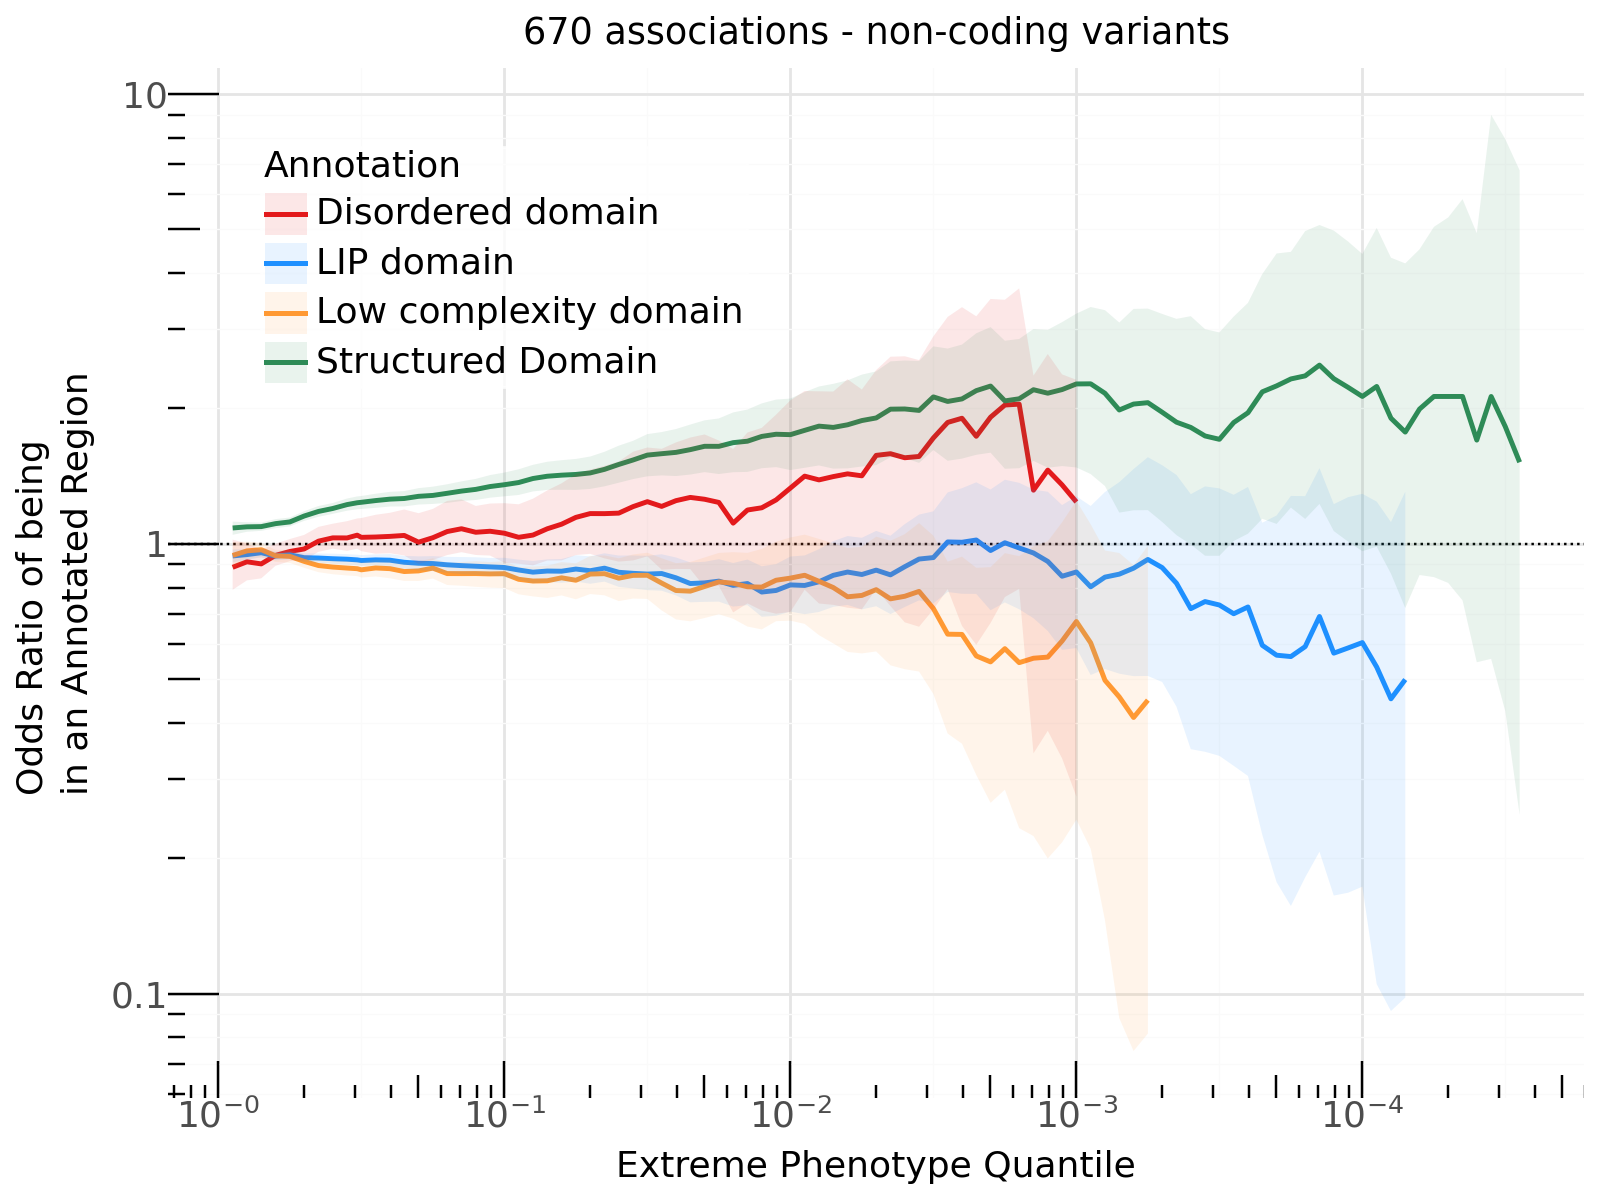

In [10]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (~pl.col('annotation').is_in(['not_annotated_in_encode', 'encode_annotated']))
        # (pl.col('annotation').is_in(['deletion', 'deletion_gt2bp', 'deletion_gt5bp']))
        # (pl.col('annotation').is_in(['insertion', 'insertion_gt2bp', 'insertion_gt5bp']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_left))
end_exp = int(-np.log10(or_threshold_pheno_right))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{-{int(b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        aes(x='neg_log_pheno_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{gene_trait_df.shape[0]} associations - non-coding variants",
        y=f"Odds Ratio of being\nin an Annotated Region",
        x="Extreme Phenotype Quantile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
plt_df.filter(pl.col('pheno_cutoff') == 0.6730)

annotation,pheno_cutoff,zscore_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio,ci_lower,ci_upper,pheno_cutoff_inv,neg_log_pheno_cutoff_inv,color,label
str,f32,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str
"""low_complexity_domain""",0.673,0.448212,4003,11753,90391,233768,0.880839,0.848098,0.91406,0.327,0.485452,"""#FF9933""","""Low complexity domain"""
"""mobi_curated_disorder_priority""",0.673,0.448212,1248,3106,93146,242415,1.045703,0.975648,1.139063,0.327,0.485452,"""#E31A1C""","""Disordered domain"""
"""mobi_lip_full""",0.673,0.448212,19490,54063,74904,191458,0.921468,0.895954,0.946175,0.327,0.485452,"""#1E90FF""","""LIP domain"""
"""ted_domain""",0.673,0.448212,33365,75362,61029,170159,1.234404,1.194073,1.274945,0.327,0.485452,"""#2E8B57""","""Structured Domain"""


In [12]:
# --- Save reference OR points for reuse in continuous annotation notebooks ---
# Set this label to describe the variant filter used in this run
# variant_filter_label = "Gene body"   # ← change per run: "Gene body", "CDS", "Non-CDS", "Intronic", etc.

RAP_REF_OR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/odds_ratio_results'
ref_or_local = f'{LOCAL_APPV_DIR}/category_or_reference_points.tsv'

# Count annotated variants (score == 1) per annotation
n_annotated_per_anno = (
    melted_anno
    .filter(pl.col('annotation_score_dircor') == 1)
    .group_by('annotation')
    .agg(n_variants = pl.len().cast(pl.Int64))
)

# Tag this run's results with variant filter label and per-annotation variant count
run_results = (
    plt_df
    .filter(pl.col('pheno_cutoff') == 0.6730)
    .with_columns(variant_filter = pl.lit(variant_filter_label))
    .join(n_annotated_per_anno, on='annotation', how='left')
)

# Try to download existing file; if it doesn't exist, start fresh
!dx download {RAP_REF_OR}/category_or_reference_points.tsv -o {ref_or_local} -f 2>/dev/null || echo "No existing file, starting fresh"

import os
if os.path.exists(ref_or_local):
    existing = pl.read_csv(ref_or_local, separator='\t')
    # Remove stale entries for same (variant_filter, annotation)
    new_keys = run_results.select(['variant_filter', 'annotation']).unique()
    existing = existing.join(new_keys, on=['variant_filter', 'annotation'], how='anti')
    combined = pl.concat([existing, run_results], how='vertical_relaxed')
    print(f"Appended to existing file ({existing.shape[0]} old + {run_results.shape[0]} new)")
else:
    combined = run_results
    print(f"Starting fresh file ({run_results.shape[0]} rows)")

combined.write_csv(ref_or_local, separator='\t')

# Upload to DNAnexus
!dx mkdir -p {RAP_REF_OR}
!dx rm {RAP_REF_OR}/category_or_reference_points.tsv -f 2>/dev/null || echo "No existing file to remove, proceeding to upload"
!dx upload {ref_or_local} --path {RAP_REF_OR}/

Appended to existing file (2 old + 4 new)
[===========================================================>] Uploaded 1,501 of 1,501 bytes (100%) /home/dnanexus/data_dir/category_or_reference_points.tsvsv
ID                                file-J69PYxjJg0yPX3qZkjk8VjZB
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym/odds_ratio_results
Name                              category_or_reference_points.tsv
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Mon Feb 16 11:05:27 2026
Created by                        shubhankar
 via the job                      job-J69GJK0Jg0yFY68p5xyFVBJv
Last modified                     Mon Feb 16 11:05:28 2026
Media type                      

In [13]:
print(f"\nSaved {combined.shape[0]} reference points to {RAP_REF_OR}/category_or_reference_points.tsv")
print(f"Variant filters: {sorted(combined['variant_filter'].unique().to_list())}")
print(f"Annotations: {sorted(combined['annotation'].unique().to_list())}")
print(f"\nAnnotated variant counts for this run:")
print(n_annotated_per_anno.sort('annotation'))


Saved 6 reference points to project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/odds_ratio_results/category_or_reference_points.tsv
Variant filters: ['Gene body', 'missense']
Annotations: ['loftee_hc', 'loftee_lc', 'low_complexity_domain', 'mobi_curated_disorder_priority', 'mobi_lip_full', 'ted_domain']

Annotated variant counts for this run:
shape: (4, 2)
┌────────────────────────────────┬────────────┐
│ annotation                     ┆ n_variants │
│ ---                            ┆ ---        │
│ str                            ┆ i64        │
╞════════════════════════════════╪════════════╡
│ low_complexity_domain          ┆ 17650      │
│ mobi_curated_disorder_priority ┆ 4845       │
│ mobi_lip_full                  ┆ 82311      │
│ ted_domain                     ┆ 120874     │
└────────────────────────────────┴────────────┘
